In [1]:
#! TODO LIST: 
# 1. environment map growth through visits
# 2. only harves, not exploration

from earth_moving.scenarios.fedeoli_beavers_scenario import fedeoli_beavers_scenario

beavers_running_config = {
    'backend_type': 'beavers_visualizer',    
    'environment':
        {
          'name': 'beavers_environment',
          'map_mode': 'csv',
          'elevation_file_path': '/home/fedeoli/Documents/Work/Projects/pushing_ws/earth_moving/earth_moving/clutter/csv_analysis/output/elevation_matrix.npy',  # Path to the CSV or NPY file
          'latitude_file_path': '/home/fedeoli/Documents/Work/Projects/pushing_ws/earth_moving/earth_moving/clutter/csv_analysis/output/latitude_coords.npy',
          'longitude_file_path': '/home/fedeoli/Documents/Work/Projects/pushing_ws/earth_moving/earth_moving/clutter/csv_analysis/output/longitude_coords.npy',
          'csv_center': [3000, 2500],  # Adjust based on your matrix center
          'width': 5000,
          'height': 5000,                            
          'vegetation_quality_range' : [1, 10],
          'streams_width': 8,
          'vegetation_quality_init_range': [6, 7],    
          'print': False,      
        },   
    'robot':
        {
            'name': 'beavers_robot',
            'range_x': [280, 320],                    # [0, width]  (check environment width)
            'range_y': [140, 160],                    # [0, height] (check environment height)
            'position': 'random',                  # 'random' or [x, y] according to the ranges below
            'home_base_position': [300, 150],        # [x, y] according to the ranges below            
            'initial_load': 0,                      # 'random' or [0, maximum_load]
            'maximum_load': 200,
            'initial_energy': 100,                  # [0, 100] - hard coded                        
            'motion_consumption': 0,                # positive, the minus will be handled in the class __init__
            'load_consumption': 0,                  # positive, the minus will be handled in the class __init__
            'harvest_consumption': 0,               # positive, the minus will be handled in the class __init__
            'harvest_threshold': [3, 9],           # [min_quality + 1, max_quality] (check environment vegetation_quality_range)
            'vegetation_removal': 0.5,
            'sleep_recovery': 1,
            'measurement_mode': 'full_map',
            'exploration_mode': 'gradient_D40',     # 'random' and/or 'D4' or 'gradient_D4' or 'gradient_D8'            
            'exploration_map': 'vegetation_visits',        # 'vegetation_visits' or 'vegetation'
            'exploration_eta': 1.0,
            'exploration_N_recovery': 40,
            'print': False,
            'controller': {                
                'name':'P_repulsive',
                'Kp': 1,                 
                'map_repulsive': 'vegetation_visits',
                'neighbourhood_size': 40,
                'visits_reset': 0.95,
                'beta_repulsive': 0.9,                
                'vegetation_barrier': [0.0, 0.01],
                'river_barrier': -0.1,
                'max':1.0,
                'accuracy':1e-2,
                'dimension':2,
            },
            'dynamics': {
                'name':'integrator',
                'mass':1.0,         #? Do we need to implement beavers with different masses? Does it depend on the load?
                'friction':1.0      #? Do we need to implement beavers with different frictions? Does it depend on the environment?
            }
        },
    'simulation':
        {
            'seed': 10,
            'timedelta': 1.0,
            'schedule_policy': 'sequential',                   # 'random' or 'sequential'
            'gui': True,
            'number_of_agents': 20,
            'print': True,
            'number_of_steps': 1,
            'downsampling': 24*30,
        },    
    }

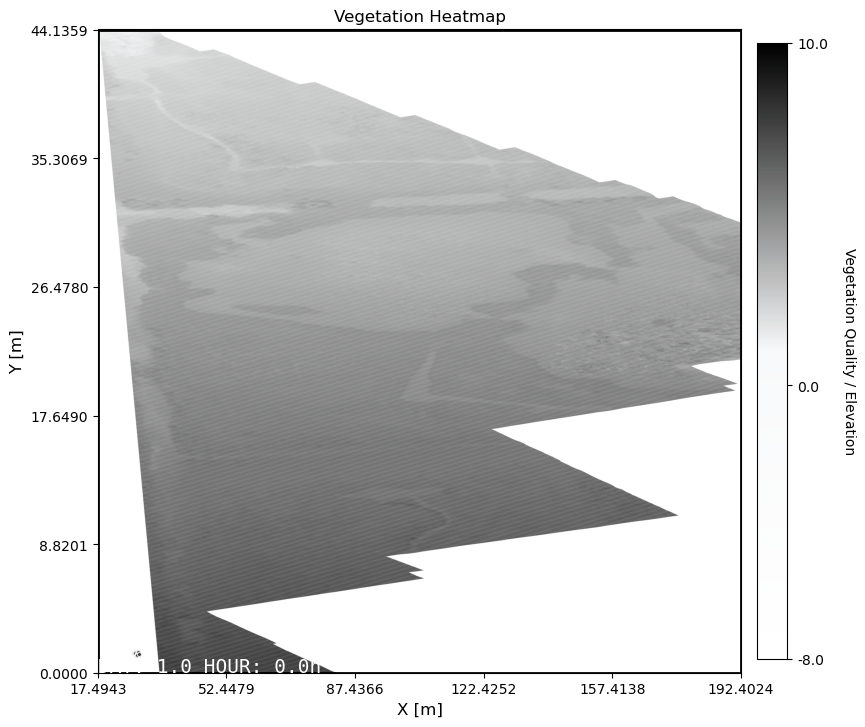

In [2]:
fedeoli_beavers_scenario(beavers_running_config)